In [11]:
import pandas as pd

tweets_trainset = pd.read_csv('data/TweetsTrainset.txt', sep='\t', header=None)
display(tweets_trainset.head(10))
print(f"Shape: {tweets_trainset.shape}")

,0,1,2
0,1,LOC/Thai Buddhist temple;,"2,000 fetuses found hidden at Thai Buddhist te..."
1,2,LOC/canada;,"870, 000 people in canada depend on #FakeHasht..."
2,3,PER/louis;,"7961212234, phone this girl! she is like louis..."
3,4,ORG/WikiLeaks;LOC/Southern Ocean;,@FakeUsername : WikiLeaks Set To Reveal US-UFO...
4,5,ORG/queen;,"@FakeUsername queen, bohemian rhapsody please"
5,6,PER/cheryl cole;PER/Danni;PER/eddie;,cheryl cole is starting to lose that connectio...
6,7,ORG/Lester;MISC/Mason & Begg Limited;,"Lester, '' Mason & Begg Limited : '' '' `Forbi..."
7,8,PER/Thomas Watson;,"To be successful, you have to have your heart ..."
8,9,"PER/Sanchez;PER/Eli Wallach;MISC/The Good, The...","Sanchez looks like Eli Wallach in The Good, Th..."
9,10,NaN,"@FakeUsername the history of the mayor, the ci..."


Shape: (2815, 3)


In [12]:
import re
import pandas as pd
from collections import Counter
import nltk

# BIO Tagging Alignment
print("BIO Tagging Alignment\n" + "="*70)

# Helper function: Find entity positions in text
def find_entities(text, entities_dict):
    """Find character positions of all entities in text"""
    entity_spans = {}
    for ent_type, names in entities_dict.items():
        entity_spans[ent_type] = []
        for name in names:
            pattern = re.compile(re.escape(name), re.IGNORECASE)
            for match in pattern.finditer(text):
                entity_spans[ent_type].append((match.start(), match.end()))
    return entity_spans

# Helper function: Parse entity string
def parse_entities(ent_str):
    """Parse 'TYPE/entity; ' format"""
    entities = {}
    if pd.isna(ent_str) or not str(ent_str).strip():
        return entities
    
    for pair in str(ent_str).split(';'):
        if '/' in pair:
            ent_type, name = pair.split('/', 1)
            ent_type = ent_type.strip()
            name = name.strip()
            if ent_type not in entities:
                entities[ent_type] = []
            entities[ent_type].append(name)
    return entities

# Helper function: Assign BIO tags
def get_bio_tags(tokens, positions, entity_spans):
    """Assign BIO tags to tokens based on entity positions"""
    tags = []
    for start, end, token in positions:
        tag = 'O'
        
        for ent_type, spans in entity_spans.items():
            for ent_start, ent_end in spans:
                if start >= ent_start and end <= ent_end:
                    tag = 'B-' + ent_type if start == ent_start else 'I-' + ent_type
                    break
            if tag != 'O':
                break
        tags.append(tag)
    return tags

# Process all sequences
pattern = r"(@\w+|#\w+|[\w']+|[^\w\s])"

sequences = []
for idx, row in tweets_trainset.iterrows():
    text = row[2]
    
    # Get NLTK tokens with positions
    tokens_pos = []
    for match in re.finditer(pattern, text):
        token = match.group()
        start = match.start()
        end = match.end()
        tokens_pos.append((start, end, token))
    
    # Parse and find entities
    entities = parse_entities(row[1])
    entity_spans = find_entities(text, entities)
    
    # Get tokens and tags
    tokens = [t for _, _, t in tokens_pos]
    tags = get_bio_tags(tokens, tokens_pos, entity_spans)
    
    if tokens:
        sequences.append({
            'text': text,
            'tokens': tokens,
            'tags': tags,
            'num_tokens': len(tokens)
        })


sequences_df = pd.DataFrame(sequences)

print(f"\nTotal sequences: {len(sequences_df):,}")

# Sample sequences
print("\n" + "-"*70)
print("SAMPLE SEQUENCES:\n")
for i in range(min(3, len(sequences_df))):
    s = sequences_df.iloc[i]
    print(f"Sequence {i+1}:")
    print(f"  Text:   {s['text']}")
    print(f"  Tokens: {s['tokens']}")
    print(f"  Tags:   {s['tags']}")
    print()

display(sequences_df.head(10))


BIO Tagging Alignment

Total sequences: 2,815

----------------------------------------------------------------------
SAMPLE SEQUENCES:

Sequence 1:
  Text:   2,000 fetuses found hidden at Thai Buddhist temple http://FakeURL via @FakeUsername
  Tokens: ['2', ',', '000', 'fetuses', 'found', 'hidden', 'at', 'Thai', 'Buddhist', 'temple', 'http', ':', '/', '/', 'FakeURL', 'via', '@FakeUsername']
  Tags:   ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

Sequence 2:
  Text:   870, 000 people in canada depend on #FakeHashtag -25% increase in the last 2 years - please give generously
  Tokens: ['870', ',', '000', 'people', 'in', 'canada', 'depend', 'on', '#FakeHashtag', '-', '25', '%', 'increase', 'in', 'the', 'last', '2', 'years', '-', 'please', 'give', 'generously']
  Tags:   ['O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

Sequence 3:
  Text:   7961212234, phone this girl! s

,text,tokens,tags,num_tokens
0,"2,000 fetuses found hidden at Thai Buddhist te...","[2, ,, 000, fetuses, found, hidden, at, Thai, ...","[O, O, O, O, O, O, O, B-LOC, I-LOC, I-LOC, O, ...",17
1,"870, 000 people in canada depend on #FakeHasht...","[870, ,, 000, people, in, canada, depend, on, ...","[O, O, O, O, O, B-LOC, O, O, O, O, O, O, O, O,...",22
2,"7961212234, phone this girl! she is like louis...","[7961212234, ,, phone, this, girl, !, she, is,...","[O, O, O, O, O, O, O, O, O, B-PER, O, O, O, O,...",24
3,@FakeUsername : WikiLeaks Set To Reveal US-UFO...,"[@FakeUsername, :, WikiLeaks, Set, To, Reveal,...","[O, O, B-ORG, O, O, O, O, O, O, O, O, B-LOC, I...",30
4,"@FakeUsername queen, bohemian rhapsody please","[@FakeUsername, queen, ,, bohemian, rhapsody, ...","[O, B-ORG, O, O, O, O]",6
5,cheryl cole is starting to lose that connectio...,"[cheryl, cole, is, starting, to, lose, that, c...","[B-PER, I-PER, O, O, O, O, O, O, O, O, O, O, B...",28
6,"Lester, '' Mason & Begg Limited : '' '' `Forbi...","[Lester, ,, '', Mason, &, Begg, Limited, :, ''...","[B-ORG, O, O, B-MISC, I-MISC, I-MISC, I-MISC, ...",34
7,"To be successful, you have to have your heart ...","[To, be, successful, ,, you, have, to, have, y...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",26
8,"Sanchez looks like Eli Wallach in The Good, Th...","[Sanchez, looks, like, Eli, Wallach, in, The, ...","[B-PER, O, O, B-PER, I-PER, O, B-MISC, I-MISC,...",19
9,"@FakeUsername the history of the mayor, the ci...","[@FakeUsername, the, history, of, the, mayor, ...","[O, O, O, O, O, O, O, O, O, O]",10


In [13]:
from sklearn.model_selection import train_test_split

# Train/Validation Split
print("Data Split - Train/Validation\n" + "="*70)

# Split: 80% train, 20% validation
train_df, val_df = train_test_split(sequences_df, test_size=0.2, random_state=42, shuffle=True)

def df_to_ner_format(df):
    """Convert DataFrame to list of (tokens, tags) for NER training"""
    return [(row['tokens'], row['tags']) for _, row in df.iterrows()]

train_data = df_to_ner_format(train_df)
val_data = df_to_ner_format(val_df)

print(f"Total sequences: {len(sequences_df):,}")
print(f"Training set (80%): {len(train_df):,} sequences")
print(f"Validation set (20%): {len(val_df):,} sequences")

train_true_tags = [row['tags'] for _, row in train_df.iterrows()]
val_true_tags = [row['tags'] for _, row in val_df.iterrows()]

print(f"\nTraining tags: {len(train_true_tags):,} sequences")
print(f"Validation tags: {len(val_true_tags):,} sequences")

#Check
display(train_df.head(10))
sample_tokens, sample_tags = train_data[0]
print("\nSample from Training Set:")
print(f"Tokens: {sample_tokens}")
print(f"Tags:   {sample_tags}")

Data Split - Train/Validation
Total sequences: 2,815
Training set (80%): 2,252 sequences
Validation set (20%): 563 sequences

Training tags: 2,252 sequences
Validation tags: 563 sequences


,text,tokens,tags,num_tokens
1744,Hanie gon get all that Chi Town ass he pull th...,"[Hanie, gon, get, all, that, Chi, Town, ass, h...","[B-PER, O, O, O, O, B-LOC, I-LOC, O, O, O, O, ...",13
2186,Larry Moore recording a late promo ahead of @F...,"[Larry, Moore, recording, a, late, promo, ahea...","[B-PER, I-PER, O, O, O, O, O, O, O, O, O, O, O...",18
2371,Natalie Portman : Her Evolution From Eerily Ma...,"[Natalie, Portman, :, Her, Evolution, From, Ee...","[B-PER, I-PER, O, O, O, O, O, O, O, O, O, O, O...",27
2514,People are smarter than you think . Give them ...,"[People, are, smarter, than, you, think, ., Gi...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",18
1025,@FakeUsername The fun - and the money - never ...,"[@FakeUsername, The, fun, -, and, the, money, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",19
2401,Nimrod Laments http://FakeURL,"[Nimrod, Laments, http, :, /, /, FakeURL]","[B-PER, I-PER, O, O, O, O, O]",7
644,"@FakeUsername Ima nerd, nerds aint tough right?","[@FakeUsername, Ima, nerd, ,, nerds, aint, tou...","[O, B-PER, O, O, O, O, O, O, O]",9
2252,Lol . I thought u missed that RT @FakeUsername...,"[Lol, ., I, thought, u, missed, that, RT, @Fak...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",34
461,@FakeUsername #FakeHashtag #FakeHashtag GoI ...,"[@FakeUsername, #FakeHashtag, #FakeHashtag, Go...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, B-P...",32
1868,I commented on a YouTube video http://FakeURL,"[I, commented, on, a, YouTube, video, http, :,...","[O, O, O, O, B-ORG, O, O, O, O, O, O]",11



Sample from Training Set:
Tokens: ['Hanie', 'gon', 'get', 'all', 'that', 'Chi', 'Town', 'ass', 'he', 'pull', 'this', 'one', 'off']
Tags:   ['B-PER', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'O', 'O', 'O', 'O', 'O', 'O']


In [14]:
try:
    from seqeval.metrics import precision_score, recall_score, f1_score, classification_report
except ImportError:
    print("seqeval not found.")
    %pip install seqeval

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib not found.")
    %pip install matplotlib

# Evaluation function
def evaluate_ner(y_true, y_pred, set_name="Validation"):
    """
    Evaluate NER using seqeval (works directly with BIO tags!)
    
    Args:
        y_true: List of tag sequences [['B-PER', 'I-PER', 'O']]
        y_pred: List of predicted tag sequences
    """
    print(f"\nEvaluation Results for {set_name} Set\n" + "-"*70)

    # Calculate metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Precision (Micro): {precision:.4f}")
    print(f"Recall (Micro):    {recall:.4f}")
    print(f"F1-Score (Micro):  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return {'precision': precision, 'recall': recall, 'f1': f1}

def plot_confusion_matrix(y_true, y_pred, set_name="Validation"):
    """Plot confusion matrix for BIO tags"""
    # Flatten lists
    y_true_flat = [tag for seq in y_true for tag in seq]
    y_pred_flat = [tag for seq in y_pred for tag in seq]

    all_tags = sorted(set(y_true_flat + y_pred_flat))
    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=all_tags)

    fig, ax = plt.subplots(figsize=(12, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = all_tags)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {set_name} Set")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Evaluation Framework Finished\n")

Evaluation Framework Finished



In [15]:
print("METHOD A - Rule-Based + CRF Approach\n" + "="*70)

import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize

try:
    nltk.data.find('taggers/averaged_perceptron_tagger')
except LookupError:
    nltk.download('averaged_perceptron_tagger')

print ("Feature Extraction - VARIATION A1: Basic Features\n" + "-"*70)

def word2features_A1(word, pos):
    """ Extract 11 basic features for a word.
    
    word: The word token
    pos: Part-of-speech tag of the word

    Returns a dictionary of features for sklearn-crfsuite.
    """

    features_A1 = {
        'bias' : 1.0,  # Bias term to help the model learn a baseline
        'word.lower()': word.lower(), 
        'len(word)': len(word),  # Length of the word
        'word[-2:]': word[-2:],  # Last 2 characters (suffix)
        'word[:2]': word[:2],  # First 2 characters (prefix)
        'word.isupper()': word.isupper(),  # Is the word in uppercase?
        'word.islower()': word.islower(),  # Is the word in lowercase?
        'word.istitle()': word.istitle(),  # Is the word title
        'word.isdigit()': word.isdigit(),  # Is the word a digit?
        'postag': pos,  # Tag
        'is_mention': word.startswith('@'),  # Is it a Twitter mention?
        'is_hashtag': word.startswith('#'),  # Is it a Twitter hashtag?
    }

    return features_A1

def sent2features_A1(sent):
    """
    Extract features for all words in a sentence.
    POS tag the entire sentence at once for efficiency.
    
    sent: List of tokens
    
    Returns: List of feature dictionaries (one per word)
    """
    # POS tag entire sentence at once
    pos_tags = pos_tag(sent) # Returns [(word, tag), (word, tag)]
    # Extract features for each word with its POS tag
    return [word2features_A1(word, pos) for word, pos in pos_tags]

print("\nExtracting features from TRAINING set...")
X_train_A1 = [sent2features_A1(tokens) for tokens, tags in train_data]
y_train_A1 = [tags for tokens, tags in train_data]

print(f"X_train_A1: {len(X_train_A1):,} sequences")
print(f"y_train_A1: {len(y_train_A1):,} sequences")

print("\nExtracting features from VALIDATION set...")
X_val_A1 = [sent2features_A1(tokens) for tokens, tags in val_data]
y_val_A1 = [tags for tokens, tags in val_data]

print(f"X_val_A1: {len(X_val_A1):,} sequences")
print(f"y_val_A1: {len(y_val_A1):,} sequences")

# Sample feature output
print("\n" + "="*70)
print("\nSample features for training sequence:")
sample_seq_idx_A1 = 20
sample_tokens_A1, sample_tags_A1 = train_data[sample_seq_idx_A1]
sample_features_A1 = X_train_A1[sample_seq_idx_A1]

print(f"Text: {' '.join(sample_tokens_A1)}")
print(f"Tags: {sample_tags_A1}\n")

for word_idx in range(len(sample_tokens_A1)):
    print(f"Word {word_idx}: '{sample_tokens_A1[word_idx]}' -> Tag: {sample_tags_A1[word_idx]}")
    print(f"  Features: {sample_features_A1[word_idx]}")
    print()

METHOD A - Rule-Based + CRF Approach
Feature Extraction - VARIATION A1: Basic Features
----------------------------------------------------------------------

Extracting features from TRAINING set...
X_train_A1: 2,252 sequences
y_train_A1: 2,252 sequences

Extracting features from VALIDATION set...
X_val_A1: 563 sequences
y_val_A1: 563 sequences


Sample features for training sequence:
Text: @FakeUsername yes , here we get blizzards , hurricanes and an occasional visit by Ann Murray .
Tags: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'I-PER', 'O']

Word 0: '@FakeUsername' -> Tag: O
  Features: {'bias': 1.0, 'word.lower()': '@fakeusername', 'len(word)': 13, 'word[-2:]': 'me', 'word[:2]': '@F', 'word.isupper()': False, 'word.islower()': False, 'word.istitle()': False, 'word.isdigit()': False, 'postag': 'JJ', 'is_mention': True, 'is_hashtag': False}

Word 1: 'yes' -> Tag: O
  Features: {'bias': 1.0, 'word.lower()': 'yes', 'len(word)': 3, 'word[-2:]': 'e

In [16]:
print ("Feature Extraction - VARIATION A2: Contextual Features\n" + "-"*70)

def word2features_A2(sent, i, pos_tags):
    """
    Extract contextual features for word at position i.
    Includes: current word features + previous and next word features + BOS/EOS.

    sent: List of tokens in the sentence
    i: Index of target word
    pos_tags: List of (word, POS) tuples from pos_tag(sent)

    Return: Dictionary of features for the word at position i
    """

    word = sent[i]
    pos = pos_tags[i][1]  # POS tag for current word
    
    features_A2 = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'len(word)': len(word),  # Length of the word
        'word[-2:]': word[-2:],  # Last 2 characters (suffix)
        'word[:2]': word[:2],  # First 2 characters (prefix)
        'word.isupper()': word.isupper(),
        'word.islower()': word.islower(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'postag': pos,
        'is_mention': word.startswith('@'),
        'is_hashtag': word.startswith('#'),
    }

    # Previous word features
    if i > 0:
        prev_word = sent[i-1]
        prev_pos = pos_tags[i-1][1]
        features_A2.update({
            'prev_word.lower()': prev_word.lower(),
            'prev_word.isupper()': prev_word.isupper(),
            'prev_word.isdigit()': prev_word.isdigit(),
            'prev_postag': prev_pos,
        })
    else:
        features_A2['BOS'] = True  # Beginning of sentence
        features_A2['prev_word.lower()'] = 'BOS'
        features_A2['prev_postag'] = 'BOS'
    
    # Next word features
    if i < len(sent) - 1:
        next_word = sent[i+1]
        next_pos = pos_tags[i+1][1]
        features_A2.update({
            'next_word.lower()': next_word.lower(),
            'next_word.isupper()': next_word.isupper(),
            'next_word.isdigit()': next_word.isdigit(),
            'next_postag': next_pos,
        })
    else:
        features_A2['EOS'] = True  # End of sentence
        features_A2['next_word.lower()'] = 'EOS'
        features_A2['next_postag'] = 'EOS'

    return features_A2

def sent2features_A2(sent):
    """
    Extract features for all words in a sentence using contextual features.
    
    sent: List of tokens
    
    Returns: List of feature dictionaries (one per word)
    """
    pos_tags = pos_tag(sent)
    return [word2features_A2(sent, i, pos_tags) for i in range(len(sent))]

print("\n Extracting contextual features from TRAINING set...")
X_train_A2 = [sent2features_A2(tokens) for tokens, tags in train_data]
y_train_A2 = [tags for tokens, tags in train_data]

print(f"X_train_A2: {len(X_train_A2):,} sequences")
print(f"y_train_A2: {len(y_train_A2):,} sequences")

print("\n Extracting contextual features from VALIDATION set...")
X_val_A2 = [sent2features_A2(tokens) for tokens, tags in val_data]
y_val_A2 = [tags for tokens, tags in val_data]

print(f"X_val_A2: {len(X_val_A2):,} sequences")
print(f"y_val_A2: {len(y_val_A2):,} sequences")

# Sample feature output
print ("\n" + "="*70)
print("\nSample contextual features for training sequence:")
sample_seq_idx_A2 = 20
sample_tokens_A2, sample_tags_A2 = train_data[sample_seq_idx_A2]
sample_features_A2 = X_train_A2[sample_seq_idx_A2]

print(f"Text: {' '.join(sample_tokens_A2)}")
print(f"Tags: {sample_tags_A2}\n")

for word_idx in range(len(sample_tokens_A2)):
    print(f"Word {word_idx}: '{sample_tokens_A2[word_idx]}' -> Tag: {sample_tags_A2[word_idx]}")
    print(f"  Features: {sample_features_A2[word_idx]}")
    print()

Feature Extraction - VARIATION A2: Contextual Features
----------------------------------------------------------------------

 Extracting contextual features from TRAINING set...
X_train_A2: 2,252 sequences
y_train_A2: 2,252 sequences

 Extracting contextual features from VALIDATION set...
X_val_A2: 563 sequences
y_val_A2: 563 sequences


Sample contextual features for training sequence:
Text: @FakeUsername yes , here we get blizzards , hurricanes and an occasional visit by Ann Murray .
Tags: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'I-PER', 'O']

Word 0: '@FakeUsername' -> Tag: O
  Features: {'bias': 1.0, 'word.lower()': '@fakeusername', 'len(word)': 13, 'word[-2:]': 'me', 'word[:2]': '@F', 'word.isupper()': False, 'word.islower()': False, 'word.istitle()': False, 'word.isdigit()': False, 'postag': 'JJ', 'is_mention': True, 'is_hashtag': False, 'BOS': True, 'prev_word.lower()': 'BOS', 'prev_postag': 'BOS', 'next_word.lower()': 'yes', 'next_word.

In [17]:
# Compare feature set sizes
print("\nFeature Comparison (A1 vs A2):\n")

sample_seq_idx = 20
sample_tokens, sample_tags = train_data[sample_seq_idx]
sample_features_A1 = X_train_A1[sample_seq_idx]
sample_features_A2 = X_train_A2[sample_seq_idx]

print(f"Text: {' '.join(sample_tokens)}")
print(f"Tags: {sample_tags}\n")

# Show first word
word_idx = 1
print(f"Word {word_idx}: '{sample_tokens[word_idx]}' -> Tag: {sample_tags[word_idx]}")
print(f"\nA1 Features ({len(sample_features_A1[word_idx])} features):")
for key, val in sample_features_A1[word_idx].items():
    print(f"  {key}: {val}")

print(f"\nA2 Features ({len(sample_features_A2[word_idx])} features):")
for key, val in sample_features_A2[word_idx].items():
    print(f"  {key}: {val}")


Feature Comparison (A1 vs A2):

Text: @FakeUsername yes , here we get blizzards , hurricanes and an occasional visit by Ann Murray .
Tags: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'I-PER', 'O']

Word 1: 'yes' -> Tag: O

A1 Features (12 features):
  bias: 1.0
  word.lower(): yes
  len(word): 3
  word[-2:]: es
  word[:2]: ye
  word.isupper(): False
  word.islower(): True
  word.istitle(): False
  word.isdigit(): False
  postag: UH
  is_mention: False
  is_hashtag: False

A2 Features (20 features):
  bias: 1.0
  word.lower(): yes
  len(word): 3
  word[-2:]: es
  word[:2]: ye
  word.isupper(): False
  word.islower(): True
  word.istitle(): False
  word.isdigit(): False
  postag: UH
  is_mention: False
  is_hashtag: False
  prev_word.lower(): @fakeusername
  prev_word.isupper(): False
  prev_word.isdigit(): False
  prev_postag: JJ
  next_word.lower(): ,
  next_word.isupper(): False
  next_word.isdigit(): False
  next_postag: ,


In [18]:
%pip install sklearn-crfsuite

Note: you may need to restart the kernel to use updated packages.


In [19]:
print("TRAIN CRF MODELS (A1 vs A2)\n")
print("=" *70)

import scipy
from sklearn_crfsuite import CRF
import time
from sklearn.model_selection import RandomizedSearchCV


params_space = {
    'c1': scipy.stats.expon(scale=0.5),
    'c2': scipy.stats.expon(scale=0.05),
}

def random_search_crf(X_train, y_train, model_name):
    """Perform Randomized Search for CRF hyperparameters."""
    crf = CRF(
        algorithm='lbfgs',
        max_iterations=100,
        all_possible_transitions=True,
        verbose=False
    )
    
    crf_random_search = RandomizedSearchCV(
        estimator=crf,
        param_distributions=params_space,
        cv=3, 
        n_iter=10,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    start_time = time.time()
    crf_random_search.fit(X_train, y_train)
    duration = time.time() - start_time
    print(f"\nRandomized Search for {model_name} completed in {duration:.2f} seconds")
    print(f"Best parameters for {model_name}: {crf_random_search.best_params_}")
    
    return crf_random_search

#Train A1 model
print("\nTraining CRF Model - VARIATION A1 (Basic Features)\n")
crf_A1 = random_search_crf(X_train_A1, y_train_A1, "CRF - VARIATION A1")
best_crf_A1 = crf_A1.best_estimator_
train_time_A1 = crf_A1.refit_time_
print(f"\nCRF_A1 trained successfully with best parameters!")
print(f"\nTraining time for A1: {train_time_A1:.2f} seconds")

#Make predictions on validation set
print("\nGenerating predictions for VALIDATION set using A1 model")
start_pred_time_A1 = time.time()
y_pred_A1 = best_crf_A1.predict(X_val_A1)
pred_time_A1 = time.time() - start_pred_time_A1

print(f"Predictions generated!")
print(f"Predictions time: {pred_time_A1:.4f} seconds")
print(f"Prediction shape: {len(y_pred_A1)} sequences")

#Train A2 model
print("-" * 70)
print("\nTraining CRF Model - VARIATION A2 (Contextual Features)\n")
crf_A2 = random_search_crf(X_train_A2, y_train_A2, "CRF - VARIATION A2")
best_crf_A2 = crf_A2.best_estimator_
train_time_A2 = crf_A2.refit_time_
print(f"\nCRF_A2 trained successfully with best parameters!")
print(f"\nTraining time for A2: {train_time_A2:.2f} seconds")

#Make predictions on validation set
print("\nGenerating predictions for VALIDATION set using A2 model")
start_pred_time_A2 = time.time()
y_pred_A2 = best_crf_A2.predict(X_val_A2)
pred_time_A2 = time.time() - start_pred_time_A2

print(f"Predictions generated!")
print(f"Predictions time: {pred_time_A2:.4f} seconds")
print(f"Prediction shape: {len(y_pred_A2)} sequences")

#Training Summary
print("\n" + "="*70)
print("TRAINING SUMMARY:\n")

summary_data = {
    'Model': ['CRF_A1 (Basic Features)', 'CRF_A2 (Contextual Features)'],
    'Training Time (s)': [f"{train_time_A1:.2f}", f"{train_time_A2:.2f}"],
    'Prediction Time (s)': [f"{pred_time_A1:.4f}", f"{pred_time_A2:.4f}"],
    'Num Sequences': [len(X_train_A1), len(X_train_A2)],
    'Num Features (sample word)': [len(sample_features_A1[1]), len(sample_features_A2[1])]
}

import pandas as pd
summary_df = pd.DataFrame(summary_data)
display(summary_df)

#Time comparison
time_diff = train_time_A2 - train_time_A1
print(f"\nTime difference (A2 - A1): {time_diff:.2f} seconds")

#VERRIFY PREDICTION
print("\n" + "="*70)
print("\nSample Predictions from VALIDATION set (A1 vs A2):\n")

sample_seq_idx = 10
sample_tokens, sample_tags = val_data[sample_seq_idx]

print(f"Sequences {sample_seq_idx}:\n")
print(f"  Text: {' '.join(val_data[sample_seq_idx][0])}\n")
print(f"  Tokens: {sample_tokens}\n")
print(f"  True Tags: {sample_tags}\n")
print(f"  A1 predictions: {y_pred_A1[sample_seq_idx]}\n")
print(f"  A2 predictions: {y_pred_A2[sample_seq_idx]}\n")

#Compare predictions word by word
print("Word-by-word comparison:")
for word_idx in range(len(sample_tokens)):
    print(f"Word {word_idx}: '{sample_tokens[word_idx]}'")
    print(f"  True Tag: {sample_tags[word_idx]}")
    print(f"  A1 Pred:  {y_pred_A1[sample_seq_idx][word_idx]}")
    print(f"  A2 Pred:  {y_pred_A2[sample_seq_idx][word_idx]}")
    print()

print("\n BOTH CRF MODELS TRAINED")

TRAIN CRF MODELS (A1 vs A2)


Training CRF Model - VARIATION A1 (Basic Features)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Randomized Search for CRF - VARIATION A1 completed in 12.47 seconds
Best parameters for CRF - VARIATION A1: {'c1': np.float64(0.10033949437483168), 'c2': np.float64(0.010130571141612853)}

CRF_A1 trained successfully with best parameters!

Training time for A1: 2.01 seconds

Generating predictions for VALIDATION set using A1 model
Predictions generated!
Predictions time: 0.0272 seconds
Prediction shape: 563 sequences
----------------------------------------------------------------------

Training CRF Model - VARIATION A2 (Contextual Features)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Randomized Search for CRF - VARIATION A2 completed in 17.17 seconds
Best parameters for CRF - VARIATION A2: {'c1': np.float64(0.029919384304340338), 'c2': np.float64(0.10056154322399698)}

CRF_A2 trained successfully with best parameters!

Trai

,Model,Training Time (s),Prediction Time (s),Num Sequences,Num Features (sample word)
0,CRF_A1 (Basic Features),2.01,0.0272,2252,12
1,CRF_A2 (Contextual Features),3.02,0.0449,2252,20



Time difference (A2 - A1): 1.01 seconds


Sample Predictions from VALIDATION set (A1 vs A2):

Sequences 10:

  Text: #FakeHashtag Raphael Saadiq - Doing What I Can

  Tokens: ['#FakeHashtag', 'Raphael', 'Saadiq', '-', 'Doing', 'What', 'I', 'Can']

  True Tags: ['O', 'B-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O']

  A1 predictions: ['O', 'B-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O']

  A2 predictions: ['O', 'B-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O']

Word-by-word comparison:
Word 0: '#FakeHashtag'
  True Tag: O
  A1 Pred:  O
  A2 Pred:  O

Word 1: 'Raphael'
  True Tag: B-PER
  A1 Pred:  B-PER
  A2 Pred:  B-PER

Word 2: 'Saadiq'
  True Tag: I-PER
  A1 Pred:  I-PER
  A2 Pred:  I-PER

Word 3: '-'
  True Tag: O
  A1 Pred:  O
  A2 Pred:  O

Word 4: 'Doing'
  True Tag: O
  A1 Pred:  O
  A2 Pred:  O

Word 5: 'What'
  True Tag: O
  A1 Pred:  O
  A2 Pred:  O

Word 6: 'I'
  True Tag: O
  A1 Pred:  O
  A2 Pred:  O

Word 7: 'Can'
  True Tag: O
  A1 Pred:  O
  A2 Pred:  O


 BOTH CRF MODELS TRAINED


EVALUATE & COMPARE RESULTS (A1 vs A2)

Evaluating CRF_A1 (Basic Features) on VALIDATION set
----------------------------------------------------------------------

Evaluation Results for CRF_A1 (Basic Features) Set
----------------------------------------------------------------------
Precision (Micro): 0.7089
Recall (Micro):    0.5303
F1-Score (Micro):  0.6068

Classification Report:
              precision    recall  f1-score   support

         LOC       0.69      0.43      0.53       122
        MISC       0.29      0.13      0.18        47
         ORG       0.65      0.44      0.52       132
         PER       0.76      0.65      0.70       342

   micro avg       0.71      0.53      0.61       643
   macro avg       0.60      0.41      0.48       643
weighted avg       0.69      0.53      0.60       643


----------------------------------------------------------------------
EVALUATING CRF_A2 (Contextual Features) on VALIDATION SET
-----------------------------------------------

,Model,Precision,Recall,F1-Score
0,CRF_A1 (Basic),0.7089,0.5303,0.6068
1,CRF_A2 (Contextual),0.7644,0.5350,0.6295



----------------------------------------------------------------------
PERFORMANCE DIFFERENCE ANALYSIS

Precision difference (A2 - A1): +5.55%
Recall difference (A2 - A1):    +0.47%
F1-Score difference (A2 - A1):  +2.27%

----------------------------------------------------------------------
DECISION: A1 vs A2
----------------------------------------------------------------------

CHOOSE: A2 (Contextual Features)
Reason: F1-Score improved by 2.27% - contextual features provide significant value

Contextual information helps recognize entities better:
   - Previous/next word context: 2.27% F1 improvement
   - Training time increase: 1.01s

CONFUSION MATRICES

Confusion Matrix for CRF_A1 (Basic Features):


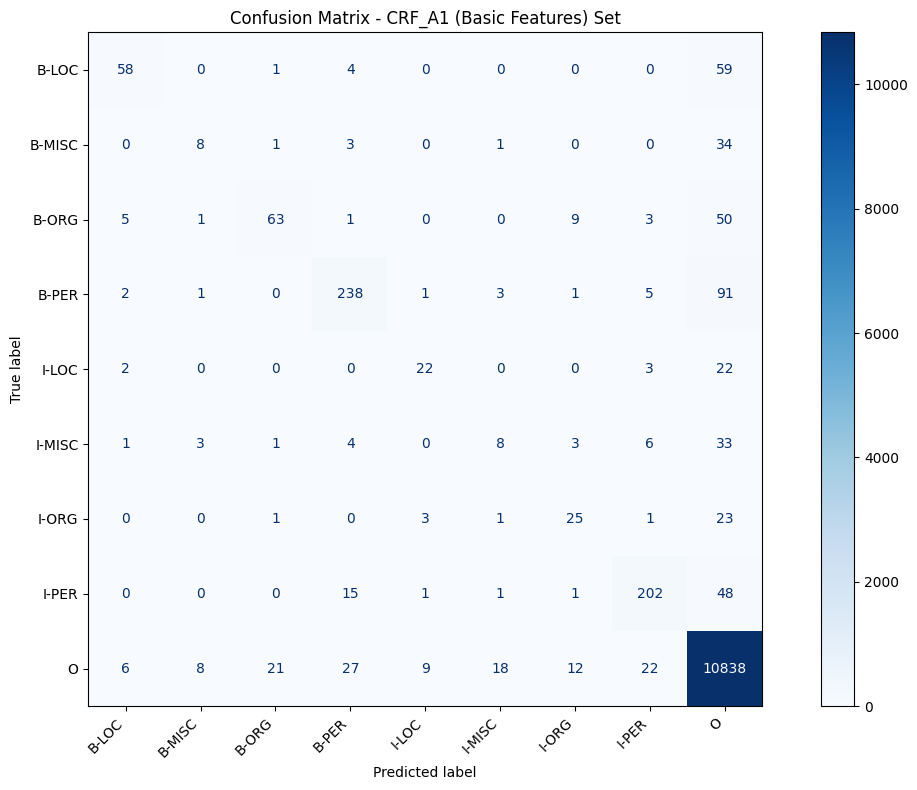


Confusion Matrix for CRF_A2 (Contextual Features):


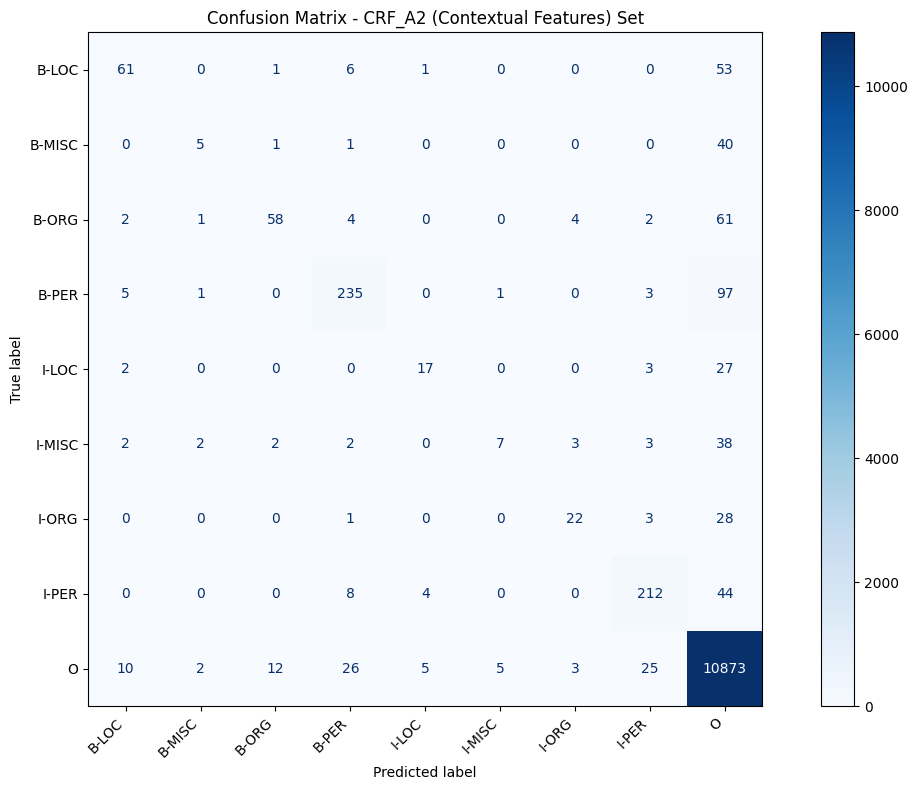

In [20]:
print("EVALUATE & COMPARE RESULTS (A1 vs A2)\n" + "="*70)

# Evaluate A1 model
print ("\nEvaluating CRF_A1 (Basic Features) on VALIDATION set")
print("-" * 70)

metrics_A1 = evaluate_ner(val_true_tags, y_pred_A1, set_name="CRF_A1 (Basic Features)")

# Evaluate A2 model
print("\n" + "-"*70)
print("EVALUATING CRF_A2 (Contextual Features) on VALIDATION SET")
print("-"*70)

metrics_A2 = evaluate_ner(val_true_tags, y_pred_A2, set_name="CRF_A2 (Contextual Features)")

# Compare metrics
print("\n" + "="*70)
print("METRICS COMPARISON TABLE")
print("="*70 + "\n")

comparison_data = {
    'Model': ['CRF_A1 (Basic)', 'CRF_A2 (Contextual)'],
    'Precision': [f"{metrics_A1['precision']:.4f}", f"{metrics_A2['precision']:.4f}"],
    'Recall': [f"{metrics_A1['recall']:.4f}", f"{metrics_A2['recall']:.4f}"],
    'F1-Score': [f"{metrics_A1['f1']:.4f}", f"{metrics_A2['f1']:.4f}"],
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# PERFORMANCE DIFFERENCE ANALYSIS

print("\n" + "-"*70)
print("PERFORMANCE DIFFERENCE ANALYSIS\n")

precision_diff = (metrics_A2['precision'] - metrics_A1['precision']) * 100
recall_diff = (metrics_A2['recall'] - metrics_A1['recall']) * 100
f1_diff = (metrics_A2['f1'] - metrics_A1['f1']) * 100

print(f"Precision difference (A2 - A1): {precision_diff:+.2f}%")
print(f"Recall difference (A2 - A1):    {recall_diff:+.2f}%")
print(f"F1-Score difference (A2 - A1):  {f1_diff:+.2f}%")

# DECISION: Which model is better?
print("\n" + "-"*70)
print("DECISION: A1 vs A2")
print("-"*70 + "\n")

f1_threshold = 0.01  # 1% improvement threshold

if abs(f1_diff / 100) > f1_threshold:
    if f1_diff > 0:
        winner = "A2 (Contextual Features)"
        reason = f"F1-Score improved by {f1_diff:.2f}% - contextual features provide significant value"
    else:
        winner = "A1 (Basic Features)"
        reason = f"A1 outperforms A2 by {abs(f1_diff):.2f}% - keep simpler model"
else:
    winner = "A1 (Basic Features) - RECOMMENDED"
    reason = f"No significant improvement ({f1_diff:.2f}%) - simpler model is preferable"

print(f"CHOOSE: {winner}")
print(f"Reason: {reason}")

if f1_diff > 0:
    print(f"\nContextual information helps recognize entities better:")
    print(f"   - Previous/next word context: {f1_diff:.2f}% F1 improvement")
    print(f"   - Training time increase: {(train_time_A2 - train_time_A1):.2f}s")
else:
    print(f"\n💡 Simple features are sufficient:")
    print(f"   - No significant improvement from context")
    print(f"   - Faster training: {abs(train_time_A2 - train_time_A1):.2f}s saved")

# Plot confusion matrices
print("\n" + "="*70)
print("CONFUSION MATRICES")
print("="*70)

print("\nConfusion Matrix for CRF_A1 (Basic Features):")
plot_confusion_matrix(val_true_tags, y_pred_A1, set_name="CRF_A1 (Basic Features)")

print("\nConfusion Matrix for CRF_A2 (Contextual Features):")
plot_confusion_matrix(val_true_tags, y_pred_A2, set_name="CRF_A2 (Contextual Features)")